<a href="https://colab.research.google.com/github/madan-genai/LangGraph/blob/main/LangGraph_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.3/331.3 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [51]:
!pip install langchain_google_genai sentence-transformers langchain_core

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [4]:
import os
os.environ["GEMINI_API_KEY"] = "AIzaSyA29n"

In [5]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [6]:
loader = PyPDFLoader("/content/Building applications with AI Agents.pdf")
docs = loader.load()

In [9]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [10]:
len(chunks)

457

In [26]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)


/tmp/ipython-input-3055314890.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [27]:
vector_store = FAISS.from_documents(chunks, embeddings)

In [28]:
vector_store

In [29]:
retriever = vector_store.as_retriever(search_type = "similarity", search_kwargs = {"k":2})

In [54]:
from pydantic import BaseModel, Field

class RagToolInput(BaseModel):
    query: str = Field(description="The query to retrieve relevant information from the PDF document.")

@tool(args_schema=RagToolInput)
def rag_tool(query):
  """Retrieve relevant information from the pdf document.
     Use this tool when the user asks factual / conceptual questions
     that might be answered from the stored documents.
  """
  result = retriever.invoke(query)

  context = [doc.page_content for doc in result]
  metadata = [doc.metadata for doc in result]
  return {
      "query" : query ,
      "context" : context,
      "metadata" : metadata
  }

In [55]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [56]:
class ChatState(TypedDict):
  messages : Annotated[list[BaseMessage], add_messages]

In [57]:
def chat_node(state : ChatState):
  messages = state["messages"]
  response = llm_with_tools.invoke(messages)
  return {"messages": [response]}

In [58]:
tool_node = ToolNode(tools)

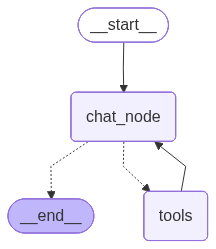

In [59]:
graph = StateGraph(ChatState)
graph.add_node("chat_node",chat_node)
graph.add_node("tools",tool_node)

graph.add_edge(START,"chat_node")
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools","chat_node")

chatbot = graph.compile()
chatbot

In [60]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain the definition of ai agents"
                )
            )
        ]
    }
)

In [62]:
(result['messages'][-1].content)

[{'type': 'text',
  'text': 'AI agents are autonomous entities developed within the field of artificial intelligence. They are designed to automate complex tasks, make intelligent decisions, and interact seamlessly with both humans and other systems. These agents are expected to revolutionize various industries due to their ability to perform these functions.',
  'extras': {'signature': 'CrMEAb4+9vtabP3SKBoFFHkw1ZaFuo/KFT9WwL6uRwzlpEoCv1YgoyzvIaL7mxY0tZo1srVFQSE9hLWMn0lm2aGeBVsomUyurAgJDelBgPfNbLuynMsaulWoS3hVJ/U7/eCDOFutSU5rxLrHPrbJ+PzaArR3/c+lL6UVteOJtZofKgOH7hoZBsS0YEzuOaIBBLBdNjotFlvjBSwgz6Fet5xHfEY5TEpVpdr18Wj9rt9iyfq/I/QqSZ7uC8kjCV9TTqw4fuXZzNO3Uxw9uG5ksHyw5rI4lTA9WOybdJGQ/qb/VcgPncIletN9W3ApkA0Ar/Mysx402VXKoXyoLmEKe4QCvxjTdBSPAbnf6azoCDtTcMTTI0+2ODO7/OmjHbQnvZL2WNwjbroVJV3Jki0JjBaJTIdBSCldSdx68bm1OwY77zVYbYulDs3maVP/Z9ednmi8I0du//sLRVc7IgD7w5TNilF8q2oTgTeeO0kXNZbLbomiGUiijLTuIgKNsq6kOlqTCtXpc1xO1G+oZdY+bdCWJpurI4V2/F88y7LmXd9cnMWHUcByqGk5y5Do9iGp43+jputC4nRxm8RRc35mBw73xuiggcNSy